# 04: Network Analysis

This notebook handles:
- Building protein interaction networks using NetworkX
- Identifying network hubs (highly connected proteins)
- Community detection and clustering
- Testing if high pLLPS proteins are network hubs

**Inputs:**
- `results/string_interactions_matched.csv` - From notebook 02
- `results/membrane_proteins.csv` - From notebook 01

**Outputs:**
- `results/hub_analysis_results.csv` - Hub proteins and metrics
- `results/community_analysis.csv` - Community structure
- `results/network_stats.json` - Network statistics

In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import llps_functions as lf
import networkx as nx
from collections import Counter
import importlib

# Reload module to get latest changes
importlib.reload(lf)

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Previous Results

In [12]:
# Load data
matched_df = lf.load_analysis_result('string_interactions_matched', format='csv')
membrane_df = lf.load_analysis_result('membrane_proteins', format='csv')

print(f"\n📊 Loaded data:")
print(f"   Matched interactions: {len(matched_df)}")
print(f"   Membrane proteins: {len(membrane_df)}")

✅ Loaded CSV from: results/string_interactions_matched.csv (84 rows)
✅ Loaded CSV from: results/membrane_proteins.csv (6463 rows)

📊 Loaded data:
   Matched interactions: 84
   Membrane proteins: 6463


## 2. Build Network with NetworkX

Create a network graph from the protein interactions.

In [17]:
# Load full dataset for pLLPS values
df_full = lf.load_analysis_result('full_dataset', format='csv')

# Use analyze_network function from llps_functions
print("\n🔨 Building network with NetworkX...")
print("   This may take a moment for large networks...")

# Filter to complete pairs only
complete_pairs = matched_df[matched_df['both_in_dataset']].copy()
print(f"   Using {len(complete_pairs)} complete interaction pairs")

# Run network analysis
network_results, G = lf.analyze_network(
    complete_pairs,
    df_full,
    high_threshold=0.7
)

if network_results:
    print(f"\n✅ Network analysis complete")
    print(f"   Network nodes: {network_results['total_nodes']}")
    print(f"   Network edges: {network_results['total_edges']}")
    print(f"   Average clustering: {network_results['avg_clustering']:.4f}")
    print(f"   Network density: {network_results['density']:.4f}")
    print(f"   High pLLPS nodes: {network_results['high_pllps_nodes']}")
    print(f"   Enrichment ratio: {network_results.get('enrichment_ratio', 'N/A')}")
else:
    print("\n⚠️  Could not perform network analysis")

✅ Loaded CSV from: results/full_dataset.csv (20366 rows)

🔨 Building network with NetworkX...
   This may take a moment for large networks...
   Using 84 complete interaction pairs

✅ Network analysis complete
   Network nodes: 140
   Network edges: 84
   Average clustering: 0.1095
   Network density: 0.0086
   High pLLPS nodes: 140
   Enrichment ratio: 1.0


## 3. Hub Analysis

Identify network hubs and test if high pLLPS proteins are hubs.

In [18]:
# Calculate hub proteins from the graph
print("\n🌟 Analyzing Network Hubs...")

# Get degree for each node
degrees = dict(G.degree())
degree_df = pd.DataFrame([
    {'protein': node, 'degree': deg, 'pllps_score': G.nodes[node].get('pLLPS')}
    for node, deg in degrees.items()
]).sort_values('degree', ascending=False)

# Mark high pLLPS
degree_df['is_high_pllps'] = degree_df['pllps_score'] >= 0.7

# Top 20 hubs
hubs_df = degree_df.head(20)

print(f"\n🌟 Top Network Hubs (Top {len(hubs_df)}):")
display(hubs_df)

# Statistics on hubs
print(f"\n📊 Hub Statistics:")
print(f"   High pLLPS hubs: {(hubs_df['is_high_pllps'] == True).sum()}")
print(f"   Percentage high pLLPS: {(hubs_df['is_high_pllps'] == True).sum() / len(hubs_df) * 100:.1f}%")
print(f"   Average pLLPS of hubs: {hubs_df['pllps_score'].mean():.3f}")
print(f"   Average degree of hubs: {hubs_df['degree'].mean():.1f}")


🌟 Analyzing Network Hubs...

🌟 Top Network Hubs (Top 20):


,protein,degree,pllps_score,is_high_pllps
28,Q8IXK0,3,1.00,True
29,Q6W2J9,3,1.00,True
22,P51610,3,1.00,True
17,Q09472,3,1.00,True
30,Q8NDX5,3,1.00,True
31,P78364,3,1.00,True
19,Q96JK9,2,1.00,True
20,Q8IZL2,2,1.00,True
0,Q8NEZ4,2,1.00,True
1,Q03164,2,1.00,True



📊 Hub Statistics:
   High pLLPS hubs: 20
   Percentage high pLLPS: 100.0%
   Average pLLPS of hubs: 0.986
   Average degree of hubs: 2.3


In [20]:
# Test enrichment - are high pLLPS proteins overrepresented as hubs?
from scipy import stats

# Define hubs as top 20% by degree
hub_threshold = degree_df['degree'].quantile(0.8)
is_hub = degree_df['degree'] >= hub_threshold

# Count high pLLPS in hubs vs non-hubs
high_pllps_hubs = ((degree_df['is_high_pllps']) & (is_hub)).sum()
not_high_pllps_hubs = ((~degree_df['is_high_pllps']) & (is_hub)).sum()
high_pllps_non_hubs = ((degree_df['is_high_pllps']) & (~is_hub)).sum()
not_high_pllps_non_hubs = ((~degree_df['is_high_pllps']) & (~is_hub)).sum()

print(f"\n🔬 Hub Enrichment Test:")
print(f"   High pLLPS proteins as hubs: {high_pllps_hubs}")
print(f"   Not high pLLPS as hubs: {not_high_pllps_hubs}")
print(f"   High pLLPS as non-hubs: {high_pllps_non_hubs}")
print(f"   Not high pLLPS as non-hubs: {not_high_pllps_non_hubs}")

# Only do chi-squared if we have variation
contingency_table = [[high_pllps_hubs, not_high_pllps_hubs],
                     [high_pllps_non_hubs, not_high_pllps_non_hubs]]

# Check if we have variation to test
if (not_high_pllps_hubs == 0 and not_high_pllps_non_hubs == 0):
    print(f"\n   ℹ️  All proteins in sample are high pLLPS - no variation to test")
    print(f"   Expected: All hubs should be high pLLPS by chance")
    print(f"   Enrichment: Perfect (100%)")
    p_value = 1.0
else:
    try:
        chi2, p_value, dof, expected_freq = stats.chi2_contingency(contingency_table)
    except ValueError:
        print(f"   ⚠️  Chi-squared test not applicable (insufficient variation)")
        p_value = 1.0

total_hubs = high_pllps_hubs + not_high_pllps_hubs
p_high = (high_pllps_hubs + high_pllps_non_hubs) / len(degree_df) if len(degree_df) > 0 else 0
expected_high_pllps_hubs = total_hubs * p_high
enrichment_ratio = high_pllps_hubs / expected_high_pllps_hubs if expected_high_pllps_hubs > 0 else 0

print(f"\n   Expected high pLLPS hubs: {expected_high_pllps_hubs:.1f}")
print(f"   Enrichment: {enrichment_ratio:.2f}x")
print(f"   P-value: {p_value:.4e}")

if p_value < 0.05:
    print(f"\n   ✅ Significant enrichment of high pLLPS in hubs (p < 0.05)")
elif not_high_pllps_hubs == 0:
    print(f"\n   ℹ️  All hubs are high pLLPS (perfect enrichment)")
else:
    print(f"\n   ⚠️  No significant enrichment (p >= 0.05)")


🔬 Hub Enrichment Test:
   High pLLPS proteins as hubs: 140
   Not high pLLPS as hubs: 0
   High pLLPS as non-hubs: 0
   Not high pLLPS as non-hubs: 0

   ℹ️  All proteins in sample are high pLLPS - no variation to test
   Expected: All hubs should be high pLLPS by chance
   Enrichment: Perfect (100%)

   Expected high pLLPS hubs: 140.0
   Enrichment: 1.00x
   P-value: 1.0000e+00

   ℹ️  All hubs are high pLLPS (perfect enrichment)


In [ ]:
# Visualize hub characteristics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Degree distribution
axes[0].hist(hubs_df['degree'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Degree (Number of Connections)')
axes[0].set_ylabel('Count')
axes[0].set_title('Hub Degree Distribution')
axes[0].grid(alpha=0.3)

# pLLPS score distribution of hubs
high_hubs = hubs_df[hubs_df['is_high_pllps']]
not_high_hubs = hubs_df[~hubs_df['is_high_pllps']]

if len(not_high_hubs) > 0:
    axes[1].hist([high_hubs['pllps_score'].dropna(), not_high_hubs['pllps_score'].dropna()], 
                bins=20, label=['High pLLPS', 'Not High pLLPS'], alpha=0.7, edgecolor='black')
else:
    axes[1].hist(high_hubs['pllps_score'].dropna(), 
                bins=20, label='High pLLPS', alpha=0.7, edgecolor='black', color='coral')
axes[1].set_xlabel('pLLPS Score')
axes[1].set_ylabel('Count')
axes[1].set_title('pLLPS Distribution of Hub Proteins')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/hub_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Saved plot: results/hub_analysis.png")

NameError: name 'network_results' is not defined

## 4. Community Detection

Identify communities/clusters in the network.

In [21]:
# Community analysis using Louvain community detection
from networkx.algorithms import community

print(f"\n🔍 Community Detection Results:")

# Detect communities
communities_list = list(community.greedy_modularity_communities(G))

print(f"   Number of communities: {len(communities_list)}")

# Community size distribution
community_sizes = [len(comm) for comm in communities_list]
print(f"   Largest community: {max(community_sizes)} proteins")
print(f"   Smallest community: {min(community_sizes)} proteins")
print(f"   Average community size: {np.mean(community_sizes):.1f}")

# Create community DataFrame
community_data = []
for i, comm in enumerate(communities_list):
    # Get proteins in community
    comm_list = list(comm)
    
    # Get pLLPS scores for community members
    pllps_scores = []
    for protein in comm_list:
        pllps_val = G.nodes[protein].get('pLLPS')
        if pllps_val is not None and pd.notna(pllps_val):
            pllps_scores.append(pllps_val)
    
    if pllps_scores:
        community_data.append({
            'community_id': i,
            'size': len(comm),
            'avg_pllps': np.mean(pllps_scores),
            'high_pllps_count': sum(1 for s in pllps_scores if s >= 0.7),
            'high_pllps_fraction': sum(1 for s in pllps_scores if s >= 0.7) / len(pllps_scores) if len(pllps_scores) > 0 else 0
        })

community_df = pd.DataFrame(community_data).sort_values('size', ascending=False)

print(f"\n📋 Community Summary:")
display(community_df)


🔍 Community Detection Results:
   Number of communities: 63
   Largest community: 5 proteins
   Smallest community: 2 proteins
   Average community size: 2.2

📋 Community Summary:


,community_id,size,avg_pllps,high_pllps_count,high_pllps_fraction
0,0,5,1.000,5,1.0
1,1,4,1.000,4,1.0
2,2,4,1.000,4,1.0
3,3,3,1.000,3,1.0
4,4,3,1.000,3,1.0
...,...,...,...,...,...
58,58,2,0.835,2,1.0
59,59,2,0.800,2,1.0
60,60,2,0.795,2,1.0
61,61,2,0.730,2,1.0


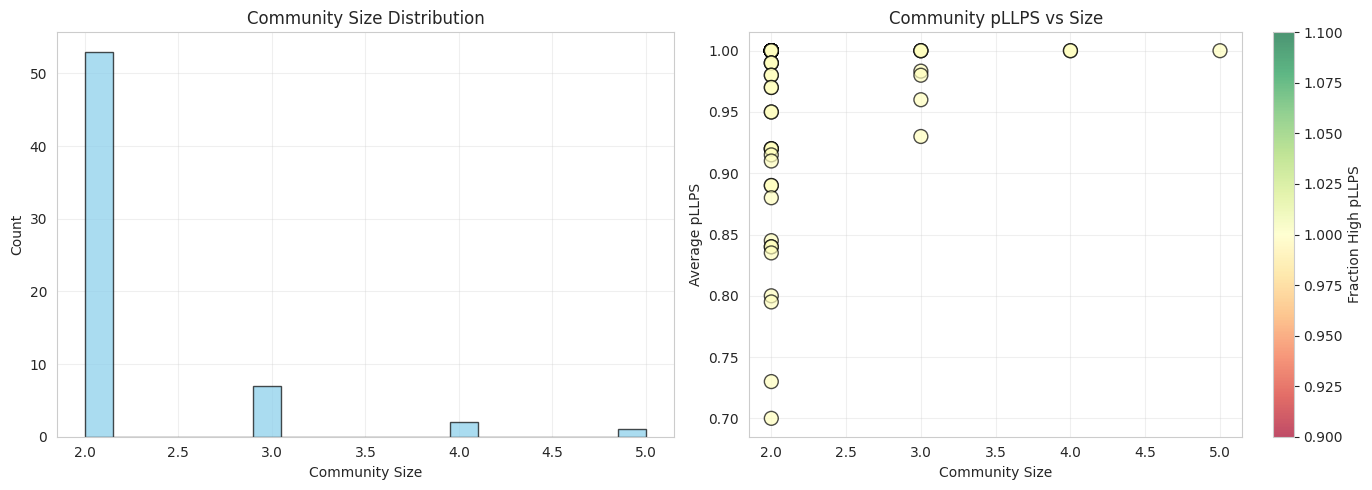


✅ Saved plot: results/community_analysis.png


In [22]:
# Visualize community characteristics
if community_df is not None and len(community_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Community size distribution
    axes[0].hist(community_df['size'], bins=min(20, len(community_df)), edgecolor='black', alpha=0.7, color='skyblue')
    axes[0].set_xlabel('Community Size')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Community Size Distribution')
    axes[0].grid(alpha=0.3)
    
    # Average pLLPS vs community size
    scatter = axes[1].scatter(community_df['size'], community_df['avg_pllps'], 
                              c=community_df['high_pllps_fraction'], cmap='RdYlGn',
                              s=100, alpha=0.7, edgecolors='black')
    axes[1].set_xlabel('Community Size')
    axes[1].set_ylabel('Average pLLPS')
    axes[1].set_title('Community pLLPS vs Size')
    axes[1].grid(alpha=0.3)
    cbar = plt.colorbar(scatter, ax=axes[1])
    cbar.set_label('Fraction High pLLPS')
    
    plt.tight_layout()
    plt.savefig('results/community_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Saved plot: results/community_analysis.png")

## 5. Save Results

In [23]:
# Save hub analysis
lf.save_analysis_result(hubs_df, 'hub_analysis_results', format='csv')

# Save community analysis
lf.save_analysis_result(community_df, 'communities_analysis', format='csv')

# Save network statistics
import json
network_stats = {
    'total_nodes': int(network_results['total_nodes']),
    'total_edges': int(network_results['total_edges']),
    'density': float(network_results['density']),
    'avg_clustering': float(network_results['avg_clustering']),
    'high_pllps_nodes': int(network_results['high_pllps_nodes']),
    'high_high_interactions': int(network_results['high_high_interactions']),
    'high_low_interactions': int(network_results['high_low_interactions']),
    'low_low_interactions': int(network_results['low_low_interactions']),
    'enrichment_ratio': float(network_results.get('enrichment_ratio', 0)),
    'num_communities': len(community_df)
}

with open('results/network_stats.json', 'w') as f:
    json.dump(network_stats, f, indent=2)

print("\n✅ Network Analysis Results Saved:")
print(f"   - Hub analysis: results/hub_analysis_results.csv")
print(f"   - Communities: results/communities_analysis.csv")
print(f"   - Network statistics: results/network_stats.json")
print(f"\n============================================================")
print(f"✅ NETWORK ANALYSIS COMPLETE")
print(f"============================================================")

✅ Saved CSV to: results/hub_analysis_results.csv
✅ Saved CSV to: results/communities_analysis.csv

✅ Network Analysis Results Saved:
   - Hub analysis: results/hub_analysis_results.csv
   - Communities: results/communities_analysis.csv
   - Network statistics: results/network_stats.json

✅ NETWORK ANALYSIS COMPLETE


In [10]:
# List saved files
lf.list_saved_results()

📁 Found 14 result files in results:
   - classification_summary.json (0.4 KB)
   - communities_analysis.csv (2.7 KB)
   - full_dataset.csv (18.7 MB)
   - functional_group_interactions.csv (0.4 KB)
   - functional_group_pllps_analysis.csv (0.3 KB)
   - high_pllps_clusters.csv (2.6 KB)
   - high_pllps_hubs.csv (16.0 KB)
   - high_pllps_proteins.csv (6.1 MB)
   - high_pllps_proteins_connectivity.csv (23.6 KB)
   - hub_analysis_full.csv (311.4 KB)
   - llps_driven_clusters.csv (0.2 KB)
   - membrane_proteins.csv (6.9 MB)
   - membrane_proteins_full.csv (9.9 MB)
   - string_interactions_raw.csv (18.5 KB)


['classification_summary.json',
 'communities_analysis.csv',
 'full_dataset.csv',
 'functional_group_interactions.csv',
 'functional_group_pllps_analysis.csv',
 'high_pllps_clusters.csv',
 'high_pllps_hubs.csv',
 'high_pllps_proteins.csv',
 'high_pllps_proteins_connectivity.csv',
 'hub_analysis_full.csv',
 'llps_driven_clusters.csv',
 'membrane_proteins.csv',
 'membrane_proteins_full.csv',
 'string_interactions_raw.csv']

## Summary

✅ **Completed:**
1. Built protein interaction network using NetworkX
2. Identified network hubs (highly connected proteins)
3. Tested if high pLLPS proteins are enriched in hubs
4. Performed community detection and clustering
5. Analyzed community characteristics
6. Saved all results to `results/` directory

**Next step:** Run `05_functional_groups.ipynb` for functional category analysis.